In [1]:
import h5py
import numpy as np    
import matplotlib.pyplot as plt
import os
import argparse
import tqdm
from matplotlib.animation import FuncAnimation, PillowWriter
%matplotlib widget

datafolder = '/travail/xgong/new_simu_highppc/output/mi25-MA40-PPC300'
plt.rcParams.update({
    # "text.usetex": True,
    "font.family": 'STIXGeneral',
    "text.latex.preamble": r"\usepackage{lmodern}",
    'mathtext.fontset': 'cm'
})

os.system('ls '+ os.path.join(datafolder, 'fields/*h5') + ' > ' + os.path.join(datafolder, 'filelist_flds.txt'))
with open(os.path.join(datafolder, 'filelist_flds.txt')) as f:
    files = f.readlines()
    for i in range(len(files)):
        files[i] = files[i].strip()
print(len(files))
fs = 15
fstick = 12


import scipy.ndimage.filters as filters

def smooth( x, window_len=61, window='hanning'):
    return filters.convolve1d(x, np.ones(window_len)/window_len)


100


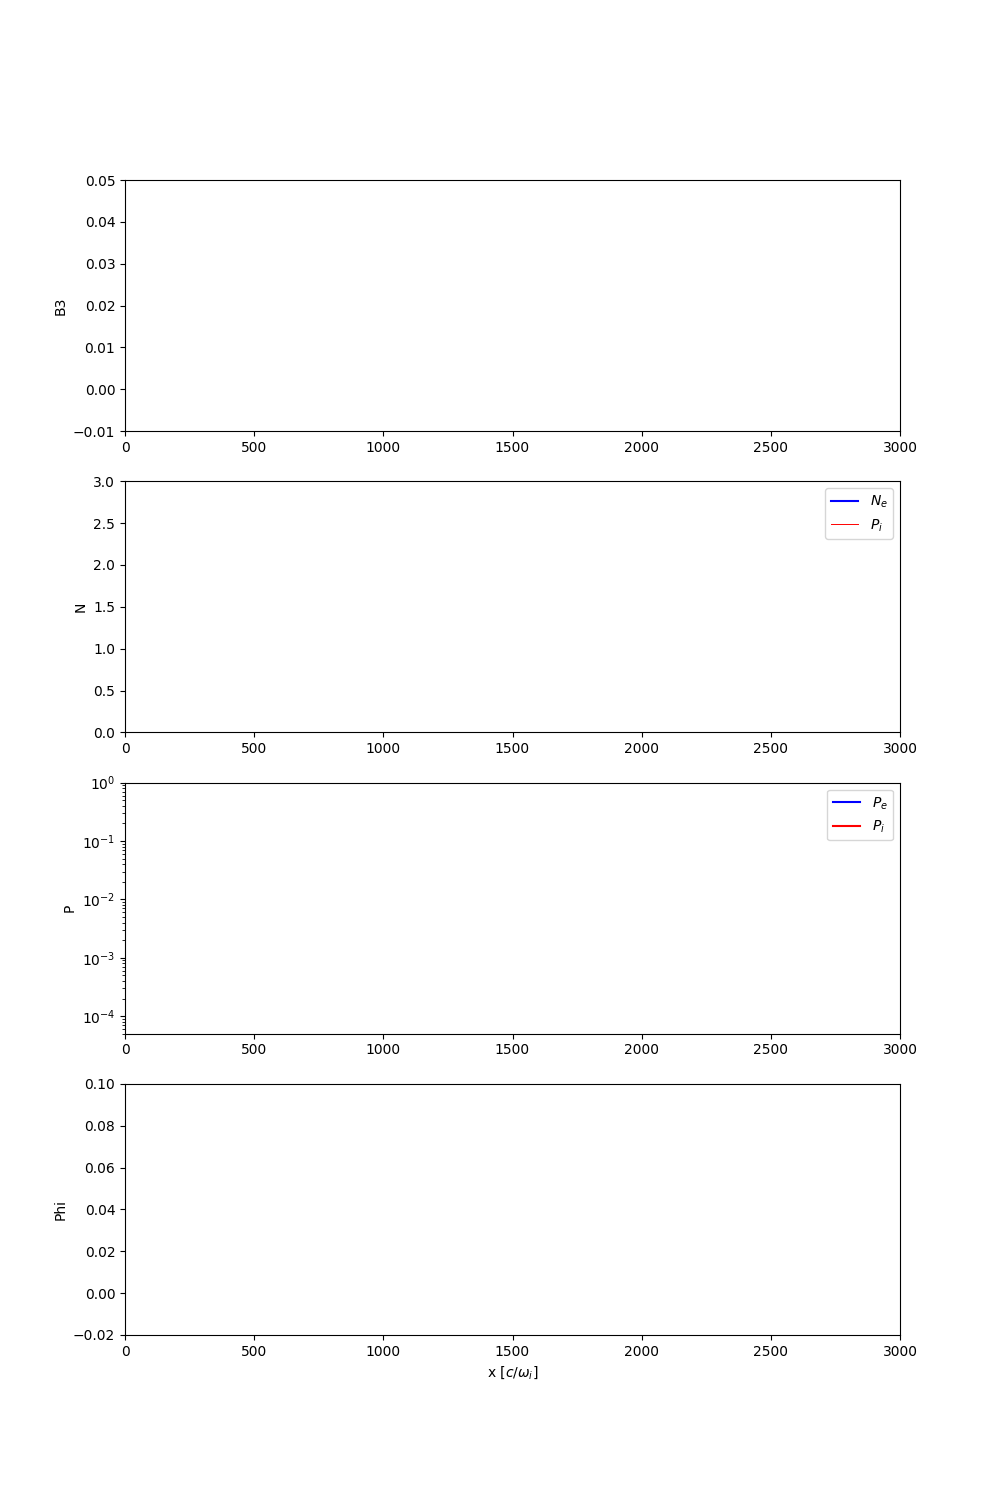

/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:71: RuntimeWarning: divide by zero encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:71: RuntimeWarning: invalid value encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:72: RuntimeWarning: divide by zero encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:72: RuntimeWarning: invalid value encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:71: RuntimeWarning: divide by zero encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:71: RuntimeWarning: invalid value encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:72: RuntimeWarning: divide by zero encountered in true_divide
/mesopsl3/home/x

In [2]:

xmin,xmax = 0,3e3
fig, (ax1, ax2, ax4, ax5) = plt.subplots(4, 1, figsize=(10, 15))

ax1.set_xlim(xmin,xmax)
ax1.set_ylim(-0.01,0.05)
# ax1.set_xlabel('x')
ax1.set_ylabel('B3')
line1, = ax1.plot([], [], color='b')

ax2.set_xlim(xmin,xmax)
ax2.set_ylim(0.0,3)
# ax2.set_xlabel('x')
ax2.set_ylabel('N')
line2, = ax2.plot([], [], color='b', label = r'$N_e$')
line3, = ax2.plot([], [], color='r', label = r'$P_i$',lw=0.7)
ax2.legend()

# ax3.set_xlim(xmin,xmax)
# ax3.set_ylim(0.0,3)
# # ax3.set_xlabel('x')
# ax3.set_ylabel('N2')
# line3, = ax3.plot([], [], color='r')

ax4.set_xlim(xmin,xmax)
# ax4.set_xlabel('x')
ax4.set_ylabel('P')
line4, = ax4.plot([], [], color='b', label = r'$P_e$')
line5, = ax4.plot([], [], color='r', label = r'$P_i$')
ax4.set_yscale('log')
ax4.set_ylim(5e-5,1e0)
ax4.legend()

ax5.set_xlim(xmin,xmax)
ax5.set_ylim(-0.02,0.1)
ax5.set_xlabel(r'x [$ c/ \omega_i$]')
ax5.set_ylabel('Phi')
line6, = ax5.plot([], [], color='r')



def stepintegrate(x,y):
    res = np.zeros_like(y)
    res = (np.cumsum(y[::-1]) * (x[1]-x[0]))[::-1]
    return res


def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    return line1, line2, line3

def update(frame_idx):
    file = h5py.File(files[frame_idx], 'r')['Step0']

    mr = 25
    T22_e = np.array(file['fT22_1'])
    T11_i = np.array(file['fT11_2'])
    T22_i = np.array(file['fT22_2'])
    Exmean = np.array(file['fAvgEx'])/10
    
    n1 = np.array(file['fN_1'])
    n2 = np.array(file['fN_2'])
    B3 = np.array(file['fB3'])
    # E1 = np.array(file['fAvgEx'])
    x1 = np.array(file['X1'])
    
    line1.set_data(x1, smooth(B3))
    line2.set_data(x1, smooth(n1))
    line3.set_data(x1, smooth(n2))
    line4.set_data(x1, smooth(T22_e / T11_i[-600:-500].mean()/mr**2))
    line5.set_data(x1, smooth(T22_i / T11_i[-600:-500].mean()))
    line6.set_data(x1, stepintegrate(x1, Exmean))
    
    return line1, line2, line3, line4, line5, line6

ani = FuncAnimation(fig, update, frames=range(0,len(files),1), init_func=init, blit=True)

# ani.save("./plots/unmag_largeppc_flds.gif", writer=PillowWriter(fps=5))
plt.show()


In [5]:

def plotndiff():
    E1_avg = None
    count = 0
    for x in tqdm.trange(-40,-1):
        count += 1
        file = h5py.File(files[x],'r+')['Step0']
        # print(file.keys())
        n1 = np.array(file['fN_1'])
        n2 = np.array(file['fN_2'])
        x1 = np.array(file['X1'])

        if E1_avg is None:
            E1_avg = n1-n2
        else: E1_avg += n1-n2
    E1_avg = E1_avg / count

    return x1, E1_avg


x1, ndiff = plotndiff()


  0%|          | 0/39 [00:00<?, ?it/s]

100%|██████████| 39/39 [00:01<00:00, 25.58it/s]


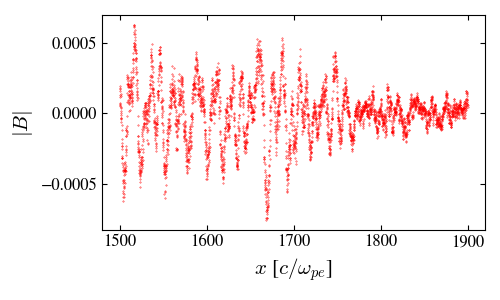

In [18]:
x = -2

file = h5py.File(files[x],'r+')['Step0']
x1 = (np.array(file['X1']))
idx = np.where((x1 > 1500) & (x1 < 1900))[0]
x1 = x1[idx]
Exmean = np.array(file['fAvgEx'])[idx]/10
B3mean = np.array(file['fAvgBz'])[idx]/10
E2mean = np.array(file['fAvgEy'])[idx]/10
Exjpt = np.array(file['fJptEx'])[idx]#/25
B1 = (np.array(file['fB1']))[idx]
B2 = (np.array(file['fB2']))[idx]
B3 = (np.array(file['fB3']))[idx]
E1 = (np.array(file['fE1']))[idx]
E2 = (np.array(file['fE2']))[idx]
E3 = (np.array(file['fE3']))[idx]
J2 = smooth(np.array(file['fJ2']), window_len=4)[idx]
N1 = smooth(np.array(file['fN_1']))[idx]
N2 = smooth(np.array(file['fN_2']))[idx]

uExB = (E2mean/B3mean)
plt.figure(figsize = (5,3))
plt.scatter(x1, smooth(N1,window_len=50)-smooth(N2,window_len=50) , color = 'red', s = 0.1)
# plt.scatter(x1,  , color = 'blue', s = 0.1)
plt.ylabel(r"$|B|$ ", fontsize = 15)
# plt.ylabel(r"$N$", fontsize = 15)
plt.xlabel(r'$x$ [$c / \omega_{pe}$]', fontsize= 15)
plt.tight_layout()
plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# plt.savefig("./plots/Bmean.png", dpi=500, bbox_size='tight')


/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:28: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_size" which is no longer supported as of 3.3 and will become an error two minor releases later


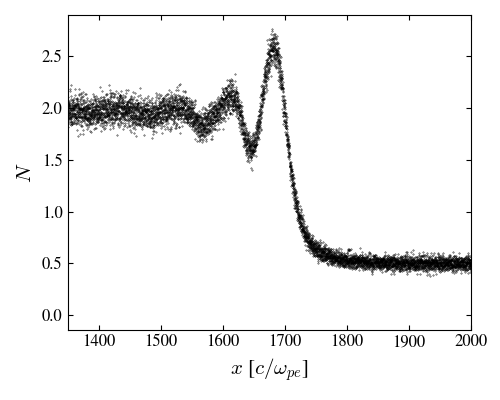

In [3]:
x = -1
file = h5py.File(files[x],'r+')['Step0']
Exmean = np.array(file['fAvgEx'])/10
Exjpt = np.array(file['fJptEx'])#/25
B1 = (np.array(file['fB1']))
B2 = (np.array(file['fB2']))
B3 = (np.array(file['fB3']))
E1 = (np.array(file['fE1']))
E2 = (np.array(file['fE2']))
E3 = (np.array(file['fE3']))
J1 = smooth(np.array(file['fJ1']), window_len=4000)
x1 = (np.array(file['X1']))
plt.figure(figsize = (5,4))
N2 = (np.array(file['fN_2']))


# plt.scatter(x1, Ex, color = 'black', s = 0.1)
# plt.scatter(x1, E2,color = 'red', s = 0.1)
# plt.scatter(x1,(smooth(np.sqrt(B1**2+B2**2+B3**2))) ,color = 'red', s = 0.1)
plt.scatter(x1, N2, color = 'black', s = 0.1)
plt.xlim(1350,2000)
plt.ylabel(r"$N$ ", fontsize = 15)
# plt.ylabel(r"$N$", fontsize = 15)
plt.xlabel(r'$x$ [$c / \omega_{pe}$]', fontsize= 15)
plt.tight_layout()
plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
plt.savefig("./plots/MA40NPrtl.png", dpi=500, bbox_size = 'tight')


Text(0.5, 0, 'X [$c / \\omega_e$]')

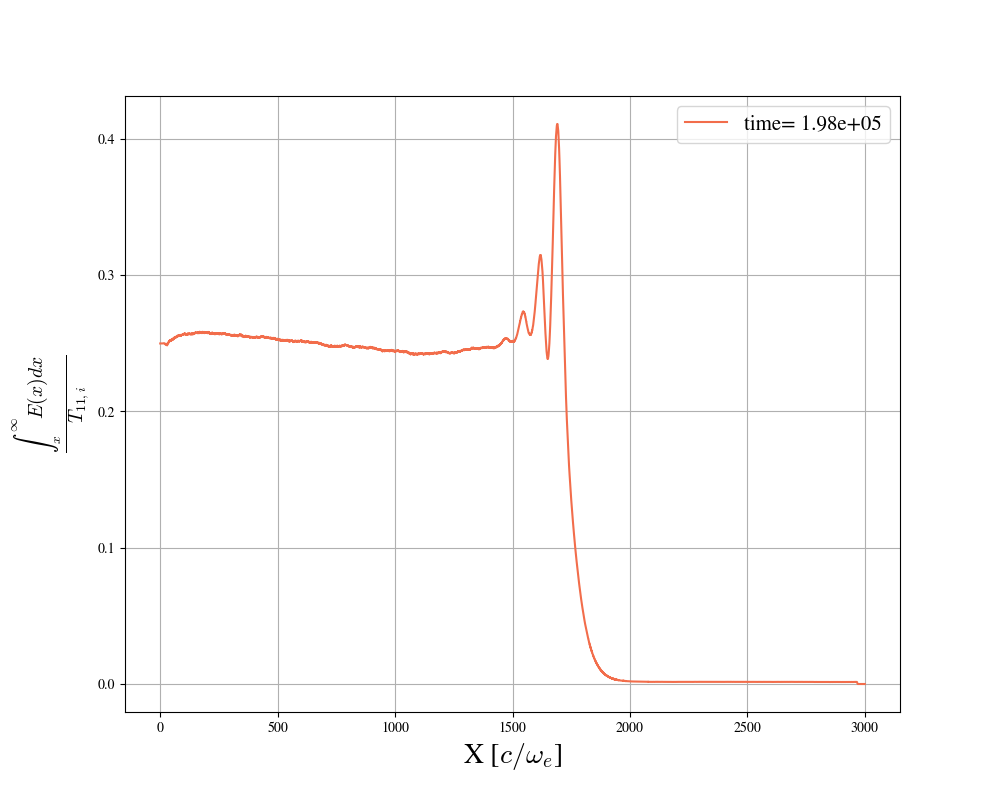

In [2]:
x = [-1]
colormap = plt.get_cmap('OrRd')
colors = colormap(np.linspace(0.6,1,len(x)))
plt.figure(figsize=(10,8))
mi=25

for i in range(len(x)):
    file = h5py.File(files[x[i]],'r+')['Step0']
    T11_i = np.array(file['fT11_2'])
    Exmean = np.array(file['fAvgEx'])/10
    Exjpt = np.array(file['fJptEx'])#/25
    Ex = np.array(file['fE1'])
    x1 = np.array(file['X1'])
    t_sim = np.array(file['Time'])
    def integrate(x,y):
        return ((y[1:]+ y[:-1])/2*(x[1:] - x[:-1])).sum()

    def stepintegrate(x,y):
        res = np.zeros_like(y)
        res = (np.cumsum(y[::-1]) * (x[1]-x[0]))[::-1]
        return res


    plt.plot(x1, stepintegrate(x1, Exmean)/T11_i[-2500]/ mi**2, color = colors[i],label='time= %.2e'%(t_sim))
    # plt.plot(x1, stepintegrate(x1, Ex))
    plt.grid()

plt.legend(fontsize =15)
plt.ylabel(r'$\frac{\int_x^\infty E(x) dx} { T_{11,i}}$', fontsize= 20)
plt.xlabel(r'X [$c / \omega_e$]', fontsize= 20)
# plt.yscale('log')
# plt.ylim(1e-5,6)
# plt.xlim(000,5000)

/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_size" which is no longer supported as of 3.3 and will become an error two minor releases later


0.3267130111855401


/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:31: RuntimeWarning: divide by zero encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in true_divide


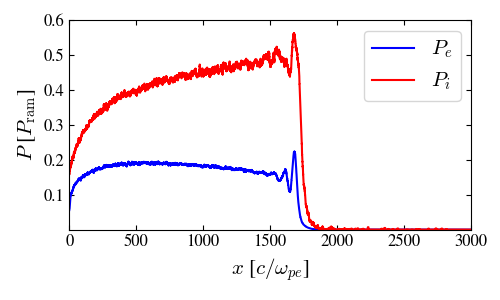

In [10]:
x =-1

mr =25

file = h5py.File(files[x],'r+')['Step0']
T11_e = np.array(file['fT11_1'])
T22_e = np.array(file['fT22_1'])
T11_i = np.array(file['fT11_2'])
# print(file.keys())
T22_i = np.array(file['fT22_2'])
x1 = np.array(file['X1'])

plt.figure(figsize = (5,3))
plt.plot(x1, smooth(T22_e / T11_i[-600:-500].mean()/ mr**2) ,markersize = 0.01,linestyle='-', color = 'blue', label=r'$P_e$')
plt.plot(x1, smooth(T22_i / T11_i[-600:-500].mean()),markersize = 0.01,linestyle='-', color = 'red', label=r'$P_i$')
# plt.scatter(x1, smooth(T11_e) ,s = 0.01, color = 'blue')
# plt.scatter(x1, smooth(T22_e /mr**2)/smooth(T22_i ) ,s = 0.01, color = 'blue')

plt.legend(fontsize=15)
# plt.scatter(x1, smooth(T11_i*mr**2),s = 0.01, color = 'red')
plt.ylim(1e-5,0.6)
plt.xlim(0,3000)
# plt.yscale('log')

plt.xlabel(r"$x$ [$c / \omega_{pe}$]", fontsize=15)
plt.ylabel(r"$P$ [$P_\mathrm{ram}$]", fontsize=15)
plt.tight_layout()
plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
plt.savefig('./plots/TemperatureRatio.png',dpi=500, bbox_size='tight')
print((T22_e / T22_i / mr**2)[16000:17000].mean())


Text(0, 0.5, 'P')

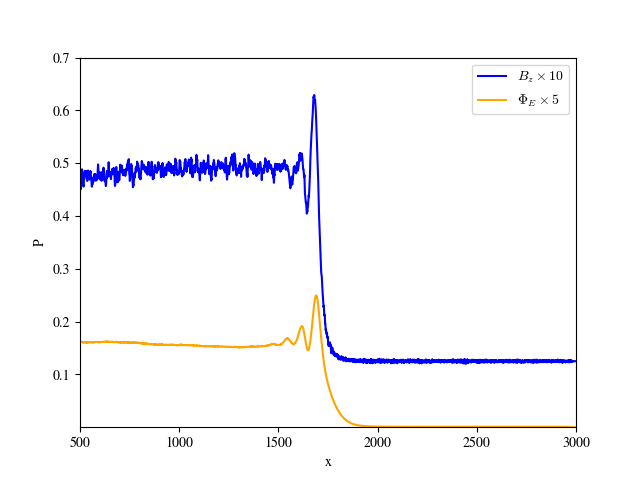

In [11]:
x =-1

mr =25

file = h5py.File(files[x],'r+')['Step0']
T11_e = np.array(file['fT11_1'])
T22_e = np.array(file['fT22_1'])
T11_i = np.array(file['fT11_2'])
# print(file.keys())
T22_i = np.array(file['fT22_2'])
B3 = np.array(file['fB3'])
Exmean = np.array(file['fAvgEx'])/10
x1 = np.array(file['X1'])
t_sim = np.array(file['Time'])
def integrate(x,y):
    return ((y[1:]+ y[:-1])/2*(x[1:] - x[:-1])).sum()

def stepintegrate(x,y):
    res = np.zeros_like(y)
    res = (np.cumsum(y[::-1]) * (x[1]-x[0]))[::-1]
    return res

x1 = np.array(file['X1'])
phi = stepintegrate(x1, Exmean)

plt.figure()
plt.plot(x1, smooth(B3) * 10 ,markersize = 0.01,linestyle='-', color = 'blue', label=r'$B_z \times 10$')
plt.plot(x1, phi * 5 ,markersize = 0.01,linestyle='-', color = 'orange', label=r'$\Phi_E \times 5$')

plt.legend()
# plt.scatter(x1, smooth(T11_i*mr**2),s = 0.01, color = 'red')
plt.ylim(1e-5,0.7)
plt.xlim(500,3000)
# plt.yscale('log')
plt.xlabel("x")
plt.ylabel("P")

/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in true_divide


KeyboardInterrupt: 

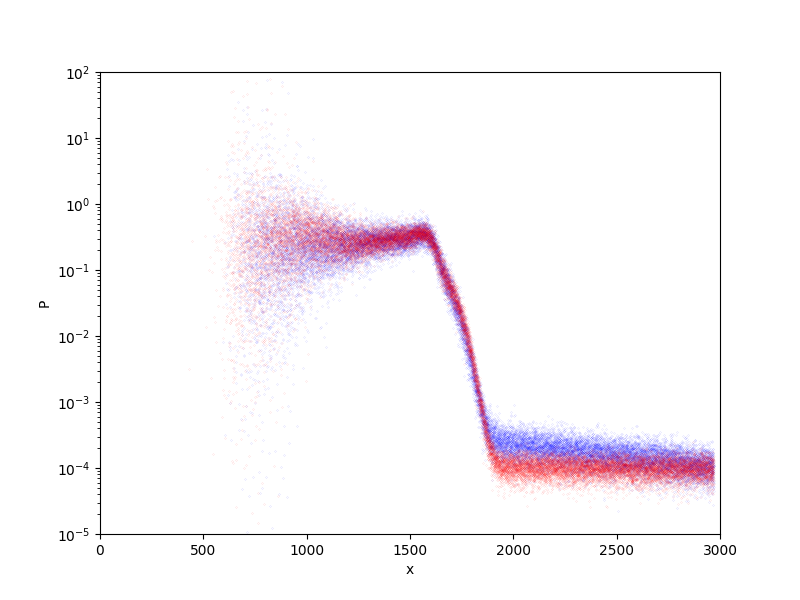

In [2]:
from matplotlib.animation import FuncAnimation, PillowWriter
fig, (ax1) = plt.subplots(figsize=(8, 6))
xmin,xmax = 0,3000
ax1.set_xlim(xmin,xmax)
ax1.set_ylim(1e-5,1e2)
ax1.set_xlabel('x')
ax1.set_ylabel('P')
ax1.set_yscale('log')
line1, = ax1.plot([], [],markersize = 0.1, marker = '.',linestyle='', color = 'blue')
line2, = ax1.plot([], [],markersize  = 0.1, marker = '.',linestyle='', color = 'red')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    return line1, line2

def update(frame_idx):
    file = h5py.File(files[frame_idx], 'r')['Step0']
    T11_e = np.array(file['fT11_1'])
    T22_e = np.array(file['fT22_1'])
    T11_i = np.array(file['fT11_2'])
    # print(file.keys())
    T22_i = np.array(file['fT22_2'])
    x1 = np.array(file['X1'])

    line1.set_data(x1, T22_e / T11_i/625)
    line2.set_data(x1, T22_i / T11_i)

    
    
    return line1, line2

ani = FuncAnimation(fig, update, frames=range(0,len(files),2), init_func=init, blit=True)

ani.save("Pressure.gif", writer=PillowWriter(fps=5))
plt.show()
